# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd


import matplotlib.pyplot as plt


import seaborn as sns
from scipy import stats


In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


**El dataset contiene 40,000 registros y 9 columnas. No se observan valores nulos en ninguna de las variables.**

**Los tipos de datos son adecuados para el análisis:** `converted` es de tipo entero y `gasto` es de tipo numérico decimal. La columna `date` aparece como tipo `object`, aunque representa fechas; sin embargo, esto no afecta el análisis estadístico que se realizará en este proyecto.

**No se identifican errores que impidan continuar con el análisis.**

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [9]:
# Resumen estadístico de usuarios que se convirtieron
df[df["converted"] == 1]["gasto"].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df["landing"].value_counts())


Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64


**Las categorías de la variable landing corresponden a las esperadas para el experimento A/B: A y B.**

Se observan **19,982 usuarios en la versión A** y **20,018 usuarios en la versión B.** Los grupos presentan una distribución equilibrada, con una diferencia de solo 36 usuarios.

No se identifican categorías mal escritas ni valores no esperados. La variable landing es consistente con la estructura definida para el experimento, por lo que se puede continuar con el análisis.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [11]:
# Gasto por versión
gasto_A = df[(df["landing"] == "A") & (df["converted"] == 1)]["gasto"]
gasto_B = df[(df["landing"] == "B") & (df["converted"] == 1)]["gasto"]

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba t para comparar el gasto promedio

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de los usuarios convertidos es igual entre las páginas A y B.
- **Hipótesis alternativa (H₁):** El gasto promedio de los usuarios convertidos es diferente entre las páginas A y B.

In [12]:
# Aplicar prueba
t_stat, p_value = stats.ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.36563589591332
Valor p: 1.0635288333792346e-20


In [13]:
#Pesos/Unidades de gasto
gasto_A.mean(), gasto_B.mean()

(61.0865724522293, 68.74536005009392)

In [14]:
#Diferencia
gasto_B.mean() - gasto_A.mean()

7.658787597864624

### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀), ya que el valor p es mucho menor que 0.05. Por lo tanto, existe una diferencia estadísticamente significativa en el gasto promedio de los usuarios convertidos entre las páginas A y B.

**Interpretación de negocio:**  
Los usuarios convertidos que visitaron la página B presentan un gasto promedio mayor que los de la página A. El gasto promedio fue de 61.09 en A y de 68.75 en B, lo que representa una diferencia de aproximadamente 7.66 unidades monetarias a favor de la página B. Esto indica que la página B genera un mayor valor económico por usuario convertido.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba de comparación de proporciones

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual entre las páginas A y B.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre las páginas A y B.

In [15]:
# Número de usuarios convertidos por página
convertidos = df[df["converted"] == 1].groupby("landing")["converted"].count()

# Total de usuarios por página
totales = df.groupby("landing")["user_id"].count()

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: user_id, dtype: int64


In [16]:
# Calcular tasa de conversión por página
tasa_conversion = convertidos / totales

print("Tasa de conversión por página:\n", tasa_conversion)

Tasa de conversión por página:
 landing
A    0.125713
B    0.159556
dtype: float64


In [17]:
# Aplicar prueba
p1 = convertidos["A"] / totales["A"]
p2 = convertidos["B"] / totales["B"]

p_pool = (convertidos["A"] + convertidos["B"]) / (totales["A"] + totales["B"])

z_stat = (p1 - p2) / ((p_pool * (1 - p_pool) * (1 / totales["A"] + 1 / totales["B"])) ** 0.5)

p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 0.0


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀), ya que el valor p es menor que 0.05. Por lo tanto, existe una diferencia estadísticamente significativa entre las tasas de conversión de las páginas A y B.

**Interpretación de negocio:**  
La página B presenta una tasa de conversión mayor que la página A. La tasa de conversión fue de 12.57% en A y de 15.96% en B, una diferencia de aproximadamente 3.38 puntos porcentuales. Esto indica que la página B es más efectiva para generar conversiones y podría ser una mejor opción para el negocio.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba de chi-cuadrado de independencia

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación significativa entre la fuente de tráfico y la conversión.
- **Hipótesis alternativa (H₁):** Existe una asociación significativa entre la fuente de tráfico y la conversión.

In [18]:
#Tabla de contingencia 
tabla_contingencia = pd.crosstab(df["traffic_source"], df["converted"])
tabla_contingencia

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [19]:
# Aplicar prueba
chi2, p_value, dof, expected = stats.chi2_contingency(tabla_contingencia)

print("Estadístico chi-cuadrado:", chi2)
print("Valor p:", p_value)

Estadístico chi-cuadrado: 8.662108841397938
Valor p: 0.0341375947833914


In [20]:
# Calcular tasa de conversión por fuente de tráfico
tasa_conversion_fuente = tabla_contingencia[1] / tabla_contingencia.sum(axis=1)

print("Tasa de conversión por fuente de tráfico:\n", tasa_conversion_fuente)

Tasa de conversión por fuente de tráfico:
 traffic_source
Ads         0.147382
Email       0.149927
Organic     0.137877
Referral    0.138812
dtype: float64


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀), ya que el valor p de la prueba de chi-cuadrado es menor que 0.05. Por lo tanto, existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.

**Interpretación de negocio:**  
La fuente de tráfico con mayor tasa de conversión es Email (14.99%), seguida de Ads (14.74%), Referral (13.88%) y Organic (13.79%). Esto sugiere que la fuente de tráfico está relacionada con la probabilidad de conversión y que Email presenta el mejor desempeño en este experimento. Para el negocio, sería conveniente analizar y fortalecer los canales con mayores tasas de conversión, especialmente Email y Ads.

***Nota:*** esto no significa que Email cause más conversiones; la prueba indica una asociación estadísticamente significativa, no causalidad.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba de chi-cuadrado de independencia

**Hipótesis:**

- **Hipótesis nula (H₀):** No existe una asociación significativa entre el tipo de usuario y la conversión.
- **Hipótesis alternativa (H₁):** Existe una asociación significativa entre el tipo de usuario y la conversión.

In [21]:
# Tabla de contingencia
tabla_contingencia = pd.crosstab(df["user_type"], df["converted"])
tabla_contingencia

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [22]:
# Calcular tasa de conversión por tipo de usuario
tasa_conversion_usuario = tabla_contingencia[1] / tabla_contingencia.sum(axis=1)

print("Tasa de conversión por tipo de usuario:\n", tasa_conversion_usuario)

Tasa de conversión por tipo de usuario:
 user_type
Nuevo         0.143587
Recurrente    0.140904
dtype: float64


In [23]:
# Aplicar prueba
chi2, p_value, dof, expected = stats.chi2_contingency(tabla_contingencia)

print("Estadístico chi-cuadrado:", chi2)
print("Valor p:", p_value)


Estadístico chi-cuadrado: 0.5134849494478645
Valor p: 0.4736341272301974


### 📝 Conclusión e interpretación

**Decisión:**
No se rechaza la hipótesis nula (H₀), ya que el valor p es mayor que 0.05. Por lo tanto, no existe evidencia estadísticamente significativa de una asociación entre el tipo de usuario y la conversión.

**Interpretación de negocio:**
Las tasas de conversión son muy similares entre los usuarios nuevos y recurrentes: **14.36%** para los usuarios nuevos y **14.09%** para los recurrentes. La diferencia es de aproximadamente **0.27 puntos porcentuales**, por lo que el tipo de usuario no parece influir significativamente en la probabilidad de conversión dentro de los datos analizados.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

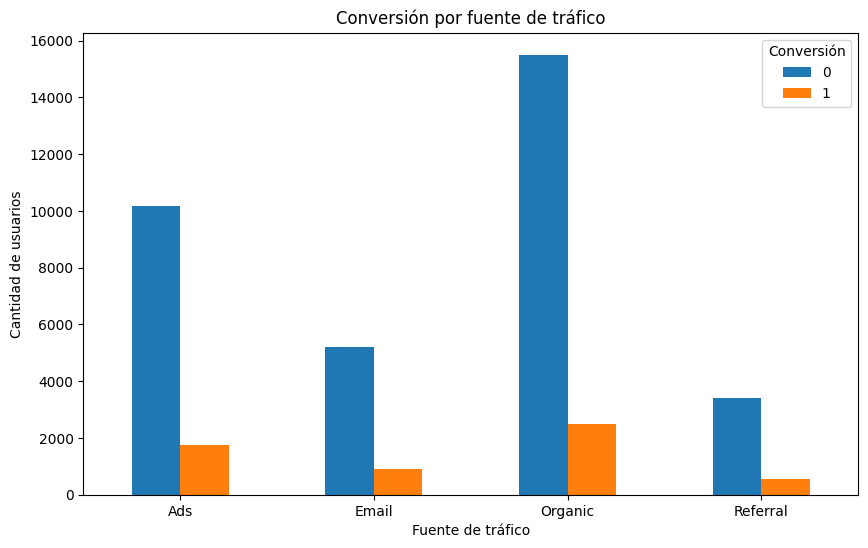

In [24]:
# Crear tabla de contingencia para fuente de tráfico
tabla_trafico = pd.crosstab(df["traffic_source"], df["converted"])

# Gráfico de usuarios convertidos y no convertidos por fuente de tráfico
tabla_trafico.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Conversión por fuente de tráfico")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Cantidad de usuarios")
plt.xticks(rotation=0)
plt.legend(title="Conversión")
plt.show()

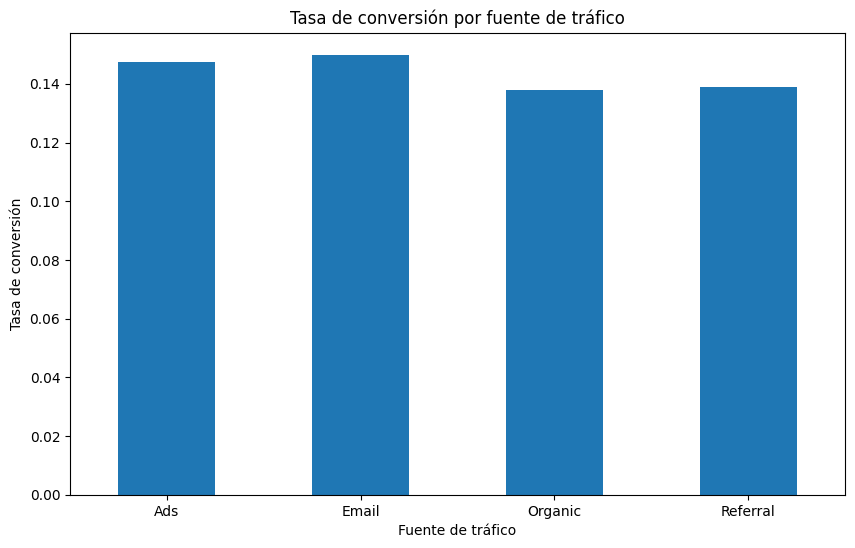

In [25]:
# Calcular y visualizar la tasa de conversión por fuente de tráfico
tasa_conversion_fuente = tabla_trafico[1] / tabla_trafico.sum(axis=1)

tasa_conversion_fuente.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Tasa de conversión por fuente de tráfico")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Tasa de conversión")
plt.xticks(rotation=0)
plt.show()

✍️ **Comentario**: 

Los gráficos muestran que, en todas las fuentes de tráfico, la cantidad de usuarios que no convierten es mayor que la cantidad de usuarios que sí convierten. Al analizar las tasas de conversión, se observa que **Email presenta la mayor tasa con 14.99%**, seguida de **Ads con 14.74%**. Por otro lado, **Referral alcanza 13.88% y Organic 13.79%**.

En términos relativos, Email y Ads muestran un mejor desempeño en conversión que Referral y Organic. Estos resultados son consistentes con la prueba de chi-cuadrado, que indicó una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.

### Relación entre el tipo de usuario y la conversión

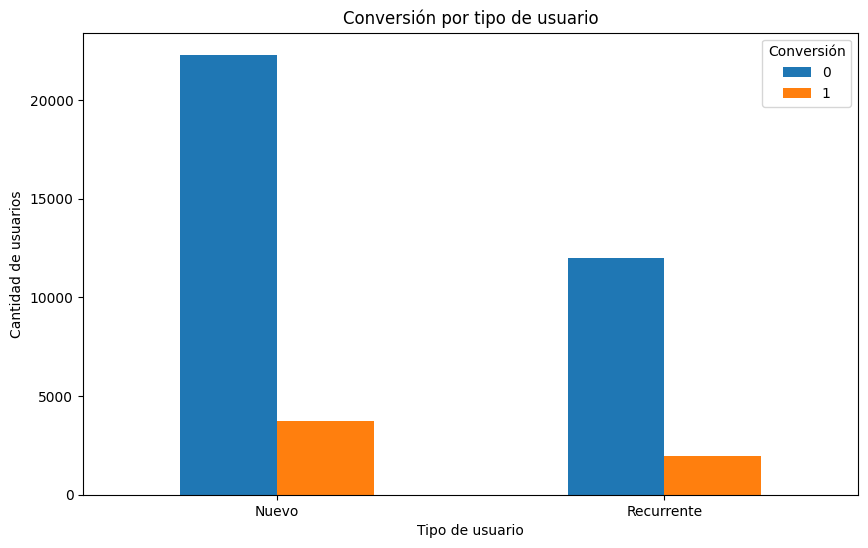

In [26]:
# Gráfico de usuarios convertidos y no convertidos por tipo de usuario
tabla_contingencia.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Conversión por tipo de usuario")
plt.xlabel("Tipo de usuario")
plt.ylabel("Cantidad de usuarios")
plt.xticks(rotation=0)
plt.legend(title="Conversión")
plt.show()

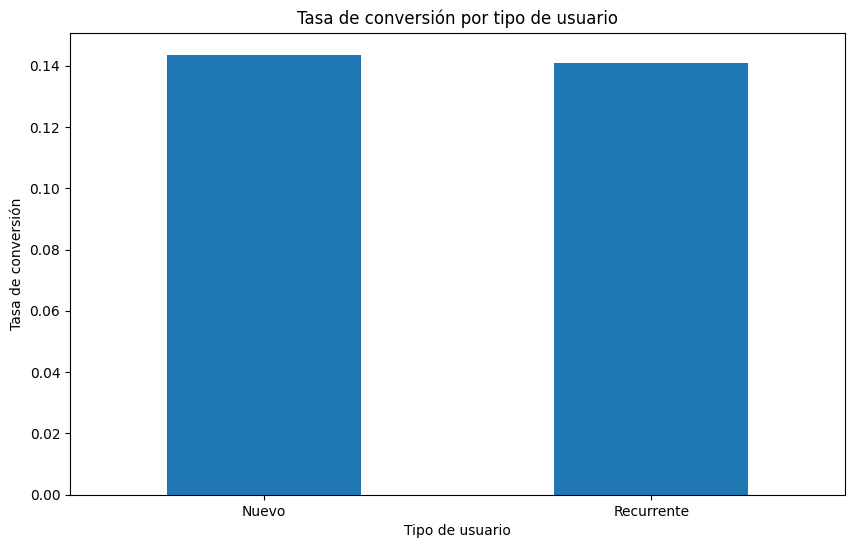

In [27]:
# Calcular y visualizar la tasa de conversión por tipo de usuario
tasa_conversion_usuario = tabla_contingencia[1] / tabla_contingencia.sum(axis=1)

tasa_conversion_usuario.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Tasa de conversión por tipo de usuario")
plt.xlabel("Tipo de usuario")
plt.ylabel("Tasa de conversión")
plt.xticks(rotation=0)
plt.show()

✍️ **Comentario**: 

Los gráficos muestran que los usuarios nuevos y recurrentes presentan tasas de conversión muy similares. Los usuarios nuevos alcanzan una tasa de **14.36%**, mientras que los usuarios recurrentes presentan una tasa de **14.09%**, con una diferencia de apenas **0.27 puntos porcentuales**.

Visualmente, las tasas son prácticamente iguales, lo que coincide con el resultado de la prueba de chi-cuadrado, donde el valor p fue mayor que 0.05. Por lo tanto, el tipo de usuario no parece tener una influencia significativa sobre la conversión en este experimento.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

1. **¿Qué página genera mayor conversión y gasto promedio?**

**La página B.** Tiene una conversión de 15.96%, frente a 12.57% de A. Además, los usuarios convertidos gastan en promedio 68.75 en B frente a 61.09 en A.

2. **¿Qué canales son más efectivos?**

**Email presenta la mayor tasa de conversión (14.99%), seguido de Ads (14.74%).** La **prueba de chi-cuadrado** mostró que sí existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión (p = 0.0341).

3. **¿Existen diferencias según el tipo de usuario?**

**No de manera estadísticamente significativa.** Los usuarios nuevos convierten 14.36% y los recurrentes 14.09%. **La diferencia es mínima (0.27 puntos porcentuales)** y la prueba de chi-cuadrado dio p = 0.4736.

4. **¿Qué recomendamos al negocio?**

*Aquí es donde podemos convertir los resultados en acciones:*

Priorizar la página B como versión de referencia, ya que mejora tanto la conversión como el gasto promedio.

Potenciar Email y Ads, que presentan las mejores tasas de conversión.

Investigar qué elementos de B están generando mejores resultados para identificar qué cambios podrían replicarse en futuras versiones.

No sería necesario crear estrategias completamente diferentes para usuarios nuevos y recurrentes basándose únicamente en estos resultados, ya que su comportamiento de conversión es muy similar.

Continuar realizando experimentos A/B para validar si las mejoras observadas en B se mantienen en otros segmentos y periodos.

---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**

**Gasto promedio por usuario que convirtió:**

- El gasto promedio fue de **61.09** unidades monetarias en la página A y de **68.75** en la página B.
- La diferencia fue de aproximadamente **7.66 unidades monetarias a favor de la página B**, y resultó estadísticamente significativa (p < 0.05).
- **Interpretación:** La página B genera un mayor gasto promedio por usuario convertido, por lo que presenta un mayor valor económico por conversión.

**Tasa de conversión:**

- La página A presentó una tasa de conversión de **12.57%**, mientras que la página B alcanzó **15.96%**.
- La diferencia fue de aproximadamente **3.38 puntos porcentuales a favor de la página B**, y resultó estadísticamente significativa (p < 0.05).
- **Interpretación:** La página B es más efectiva tanto para generar conversiones como para generar un mayor gasto promedio entre los usuarios que convierten.

---

#### 📊 **Segmentación por fuente de tráfico**

- Las tasas de conversión fueron: **Email 14.99%**, **Ads 14.74%**, **Referral 13.88%** y **Organic 13.79%**.
- **Interpretación:** Email y Ads presentan las mejores tasas de conversión. La prueba de chi-cuadrado mostró una asociación estadísticamente significativa entre la fuente de tráfico y la conversión (p = 0.0341).

---

#### 📊 **Segmentación por tipo de usuario**

- Los usuarios nuevos tuvieron una tasa de conversión de **14.36%**, mientras que los recurrentes alcanzaron **14.09%**.
- **Interpretación:** La diferencia de **0.27 puntos porcentuales** es muy pequeña y no resultó estadísticamente significativa (p = 0.4736). Por lo tanto, el tipo de usuario no parece influir significativamente en la conversión.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:**

- **Priorizar la página B** como versión de referencia, ya que presenta una mayor tasa de conversión y un mayor gasto promedio por usuario convertido.
- **Potenciar los canales Email y Ads** y analizar qué elementos de estos canales contribuyen a su mejor desempeño, manteniendo experimentos A/B para validar futuras optimizaciones.